# ZC Inflation Swap Model : Enhanced Framework

This notebook is a **companion** to `iota_trading_strategy.ipynb`.  
While the other notebook uses a simple proxy, this notebook builds a **market‑informed inflation swap proxy** that incorporates:

- CPI **index‑level** data (NSA),
- **monthly seasonality**,
- and a **CPI path** construction.

## References

This notebook follows the methodological guidance from:

- **Barclays Paper** : *Global Inflation‑Linked Products: A User’s Guide*  
- **Wanningen, C.F.A.R. (2007)** : *Inflation Derivatives*, Blue Sky Group (Thesis)

## Roadmap

We build the enhanced model in four steps:

1. **Load CPI NSA index level** (ECB data)  
2. **Estimate monthly seasonality (m/m)**  
3. **Construct a CPI path** between maturities  
4. **Derive a ZC inflation swap proxy** from the CPI path

## Step 1 : Data Sourcing

We use the **ECB Data Portal API** to retrieve the Euro area HICP index level (NSA).  
This gives the raw CPI index needed to extract **monthly seasonality** and build a CPI path.

In [11]:
# Imports
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ECB Data 
def fetch_ecb_series(dataflow: str, series_key: str, start: str = "2004-01-01") -> pd.Series:
    """Fetch a time series from the ECB Data Portal API."""
    url = (
        f"https://data-api.ecb.europa.eu/service/data/"
        f"{dataflow}/{series_key}?format=csvdata&startPeriod={start}"
    )
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    from io import StringIO
    df = pd.read_csv(StringIO(response.text))
    df = df[["TIME_PERIOD", "OBS_VALUE"]].copy()
    df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"])
    df = df.set_index("TIME_PERIOD").sort_index()
    df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
    return df["OBS_VALUE"]

In [12]:
# HICP NSA (index level) from ECB series
hicp_nsa = fetch_ecb_series("ICP", "M.U2.N.000000.4.INX", start="2004-01-01")

print(f"HICP NSA index — {len(hicp_nsa)} obs | {hicp_nsa.index[0].date()} → {hicp_nsa.index[-1].date()}")
print(f"Last HICP NSA index: {hicp_nsa.iloc[-1]:.2f}")
print(hicp_nsa.tail())

HICP NSA index — 264 obs | 2004-01-01 → 2025-12-01
Last HICP NSA index: 129.54
TIME_PERIOD
2025-08-01    129.31
2025-09-01    129.43
2025-10-01    129.70
2025-11-01    129.33
2025-12-01    129.54
Name: OBS_VALUE, dtype: float64


## Step 2 : Monthly Seasonality (m/m)

We now estimate a **12‑month seasonality vector** from the CPI NSA series.  
This captures the average **month‑to‑month inflation pattern** and will be used to build CPI paths.

In [13]:
# Monthly inflation (m/m)
hicp_mom = hicp_nsa.pct_change(1) * 100
hicp_mom_clean = hicp_mom.dropna()

# Seasonality vector: average m/m by calendar month
seasonal_bumps = hicp_mom_clean.groupby(hicp_mom_clean.index.month).mean()

# Center so the 12-month sum is ~ 0
seasonal_bumps = seasonal_bumps - seasonal_bumps.mean()

seasonality = pd.Series(
    seasonal_bumps.values,
    index=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

print("Seasonality bumps (m/m, %):")
print(seasonality.round(3))
print(f"\nCheck (sum): {seasonality.sum():.6f}")

Seasonality bumps (m/m, %):
Jan   -0.865
Feb    0.225
Mar    0.800
Apr    0.279
May    0.020
Jun    0.000
Jul   -0.487
Aug    0.001
Sep    0.170
Oct    0.106
Nov   -0.326
Dec    0.077
dtype: float64

Check (sum): 0.000000


The estimated pattern is **coherent** with typical Euro area CPI seasonality:

- **January is strongly negative**, consistent with post‑holiday price resets and sales.  
- **March–April rebound** is common as prices normalize.  
- **July dip** aligns with summer sales effects in several countries.  
- The bumps are **centered to sum ~0**, which is required to avoid biasing the CPI path.

## Step 3 : CPI Path Construction

We now build a **synthetic CPI path** by combining:
- a **trend component** (from the long‑run average m/m rate),
- and the **seasonality vector** estimated above.

This gives a monthly CPI trajectory that we can project forward for swap pricing.

In [14]:
# CPI path construction (trend + seasonality)
horizon_months = 120  # adjust as needed

# Long-run average m/m inflation (trend)
trend_mom = hicp_mom_clean.mean()  # in %

# Build forward monthly path
last_date = hicp_nsa.index[-1]
last_cpi = hicp_nsa.iloc[-1]

future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1),
                             periods=horizon_months, freq="MS")

# Map seasonality by month number
seasonality_by_month = pd.Series(seasonality.values, index=range(1, 13))

cpi_path = pd.Series(index=future_dates, dtype=float)
cpi_level = last_cpi

for dt in future_dates:
    bump = seasonality_by_month[dt.month]
    mom = trend_mom + bump
    cpi_level = cpi_level * (1 + mom / 100)
    cpi_path.loc[dt] = cpi_level

print(f"Trend m/m: {trend_mom:.4f}%")
print("First projected CPI levels:")
print(cpi_path.head())

Trend m/m: 0.1764%
First projected CPI levels:
2026-01-01    128.647468
2026-02-01    129.163603
2026-03-01    130.424996
2026-04-01    131.018825
2026-05-01    131.275782
Freq: MS, dtype: float64


The forward CPI path increases smoothly with a **trend m/m ≈ 0.176%**, 
while the monthly bumps create **realistic seasonality** (e.g., Jan dip, spring rebound).

This path is now suitable for deriving **year‑on‑year forward CPI ratios** and
building a ZC inflation swap proxy.

## Step 4 : ZC Inflation Swap Proxy

We now derive the **zero‑coupon inflation swap proxy** from the CPI path:

$$
ZC(T) = \left(\frac{CPI_T}{CPI_0}\right)^{1/T} - 1
$$

This converts the projected CPI level at maturity into an **annualized ZC rate**.

In [15]:
# Build ZC swap proxy from CPI path
cpi0 = hicp_nsa.iloc[-1]
t_years = np.arange(1, horizon_months // 12 + 1)

# CPI at each year-end in the projected path
cpi_T = cpi_path[cpi_path.index.month == cpi_path.index[0].month].iloc[:len(t_years)]

zc_proxy = (cpi_T.values / cpi0) ** (1 / t_years) - 1
zc_proxy = pd.Series(zc_proxy, index=t_years)

print("ZC proxy (annualized):")
print(zc_proxy.apply(lambda x: f"{x*100:.3f}%"))

ZC proxy (annualized):
1     -0.689%
2      0.709%
3      1.180%
4      1.416%
5      1.558%
6      1.652%
7      1.720%
8      1.771%
9      1.810%
10     1.842%
dtype: object


### Limit of our model

The curve is **upward‑sloping and smooth**, consistent with a CPI path built from
a low positive trend plus seasonality.  
The **negative 1y point is a model limitation** (base‑month seasonality effect in a simple
trend‑plus‑seasonality framework) and should not be interpreted as a realistic market level.

### Visualization

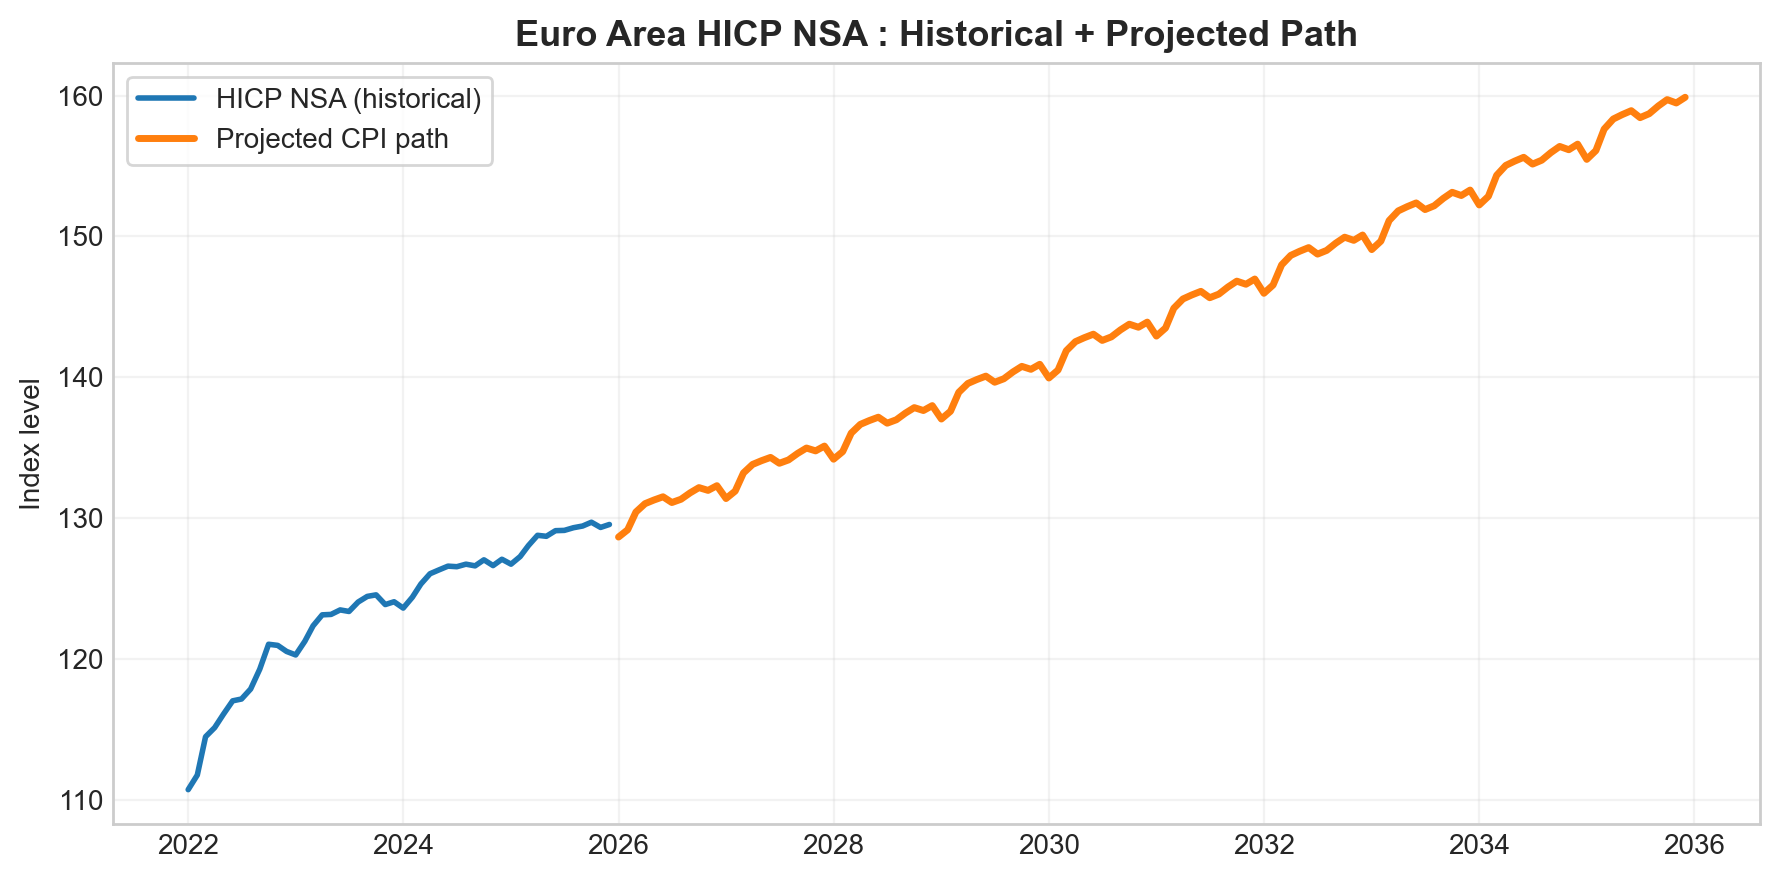

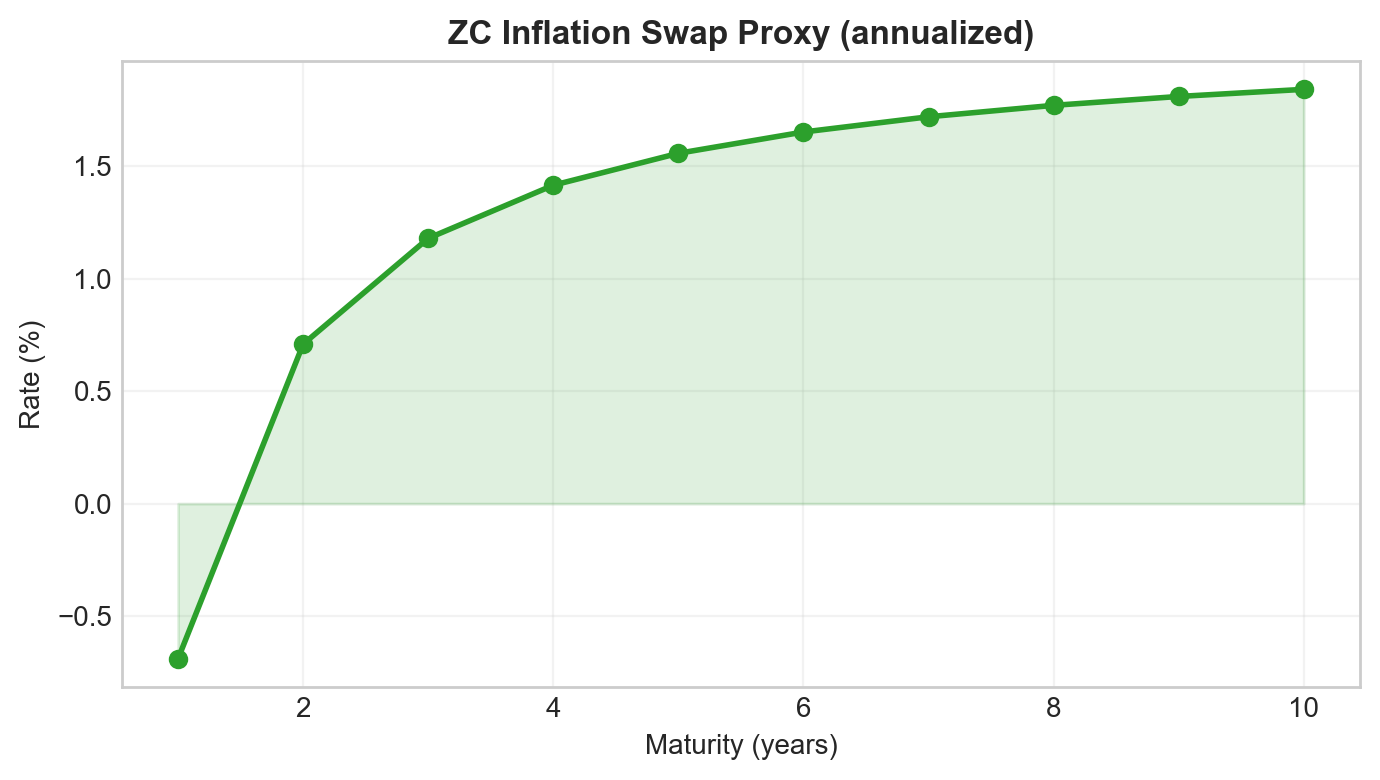

In [16]:
plt.style.use("seaborn-v0_8-whitegrid")

# CPI path plot
fig, ax = plt.subplots(figsize=(9,4.5), dpi=200)
hist = hicp_nsa.tail(48)
ax.plot(hist.index, hist.values, label="HICP NSA (historical)", color="#1f77b4", lw=2)
ax.plot(cpi_path.index, cpi_path.values, label="Projected CPI path", color="#ff7f0e", lw=2.5)

ax.set_title("Euro Area HICP NSA : Historical + Projected Path", fontsize=13, weight="bold")
ax.set_ylabel("Index level")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

# ZC proxy plot
fig, ax = plt.subplots(figsize=(7,4), dpi=200)
ax.plot(zc_proxy.index, zc_proxy.values*100, marker="o", color="#2ca02c", lw=2)
ax.fill_between(zc_proxy.index, zc_proxy.values*100, alpha=0.15, color="#2ca02c")

ax.set_title("ZC Inflation Swap Proxy (annualized)", fontsize=12, weight="bold")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Output table

With:
- projected CPI at each year‑end,
- annualized ZC proxy rate,
- and the implied cumulative inflation factor.

In [17]:
# Build outputs table
years = zc_proxy.index
cpi_T = cpi_T.values 
cum_factor = cpi_T / cpi0

outputs = pd.DataFrame({
    "CPI_T": cpi_T,
    "Cumulative_factor": cum_factor,
    "ZC_rate_%": zc_proxy.values * 100
}, index=years)

outputs.index.name = "Maturity_years"
print(outputs.round(4))

                   CPI_T  Cumulative_factor  ZC_rate_%
Maturity_years                                        
1               128.6475             0.9931    -0.6890
2               131.3842             1.0142     0.7093
3               134.1791             1.0358     1.1798
4               137.0334             1.0578     1.4158
5               139.9485             1.0803     1.5577
6               142.9256             1.1033     1.6524
7               145.9661             1.1268     1.7201
8               149.0712             1.1508     1.7709
9               152.2423             1.1753     1.8105
10              155.4809             1.2003     1.8421


The table summarizes the **projected CPI level** at each year‑end, the **cumulative
inflation factor** relative to today, and the **annualized ZC proxy**.

As before, the **negative 1y rate** reflects the model’s seasonal/base‑month limitation
and should not be treated as a market‑consistent level.

## Conclusion

We constructed a **projected CPI path** from historical NSA data using a simple
**trend + seasonality** framework, then derived an **annualized ZC inflation swap proxy**
by converting projected CPI levels into swap‑equivalent rates.

## Limitations

- **Simplified dynamics**: constant trend ignores regime shifts and macro shocks.  
- **Seasonality stability**: assumes the seasonal pattern is constant over time.  
- **No market calibration**: the ZC proxy is not fitted to actual swap quotes.  
- **Short‑end bias**: the 1y negative rate reflects **base‑month seasonality** and
  highlights a limitation of the model rather than a realistic market level.